In [1]:
import os, time

import math
import numpy as np
from numpy.polynomial.hermite import hermgauss

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LogNorm
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable 

from skrmt.ensemble.spectral_law import MarchenkoPasturDistribution

# Following options are dependant on https://github.com/chanjure/global_chanju.git
# However, this is just an aesthetic package for plotting, so it is not necessary.
from global_chanju.paulplot.styles import nice_style
from global_chanju.paulplot.rc_setter import set_rc
from global_chanju.paulplot.rc_setter import get_rc
from global_chanju.utils.statistics import asym_err
from global_chanju.utils.statistics import f_bin
from global_chanju.paulplot.styles import base_ten


set_rc() # Setting global chanju plotting scheme

In [2]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=200):
    new_cmap = LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

# 2. Non-linear models

In [3]:
def relu(x):
    return x * np.heaviside(x, 0)

def relup(x):
    return np.heaviside(x, 0)

def relupp(x):
#     return np.zeros_like(x)
    eps = 1e-15 * np.ones_like(x)
    return np.where(np.abs(x) > eps, 0., 1./eps)

In [4]:
def lines(mu1_bar, mu1_tilde, mu2_bar, mu2_tilde, sigma, r = 0.5):
    c2 = (mu2_tilde * (mu2_tilde + 2 * mu2_bar) * r * sigma**2 
          - mu2_bar**2 * np.sqrt(r) * sigma**2 
          + (mu1_bar + mu1_tilde)**2)
    c1 = 2. * (mu2_bar * np.sqrt(r) - mu2_tilde * r) * sigma**2
    c0 = - np.sqrt(r) * sigma**2
    
    eps_c_p = (-c1 + np.sqrt(c1**2 - 4 * c2 * c0))/(2. * c2)
    eps_c_n = (-c1 - np.sqrt(c1**2 - 4 * c2 * c0))/(2. * c2)
    eps_o = 1./mu2_bar
    
    eps_c_p = np.where(eps_c_p > 0, eps_c_p, np.nan)
    eps_c_n = np.where(eps_c_n > 0, eps_c_n, np.nan)
    eps_o = np.where(eps_o > 0, eps_o, np.nan)
    return eps_c_p, eps_c_n, eps_o

def epsilon_c_linear(sigma_W, r, t):
    """ Critical epsilon
    """
    return 1. - (1 + sigma_W * r**(0.25))**(-1./t)

In [5]:
plot_dir2 = "../../collected_results/figures/1.non-linear/relu/"
data_dir2 = "../../data/1.non-linear/relu/"

os.system("mkdir -p " + plot_dir2)
os.system("mkdir -p " + data_dir2)

0

In [6]:
epochs = 4
N = 100
M = 200
r = 0.5
alpha = 200

np.random.seed(42)
u = np.random.normal(0., 1., size=(N))
u /= np.linalg.norm(u)
v = np.random.normal(0., 1., size=(M))
v /= np.linalg.norm(v)

W_star = np.einsum("i, j -> ij", u, v)

In [7]:
n_x = 1000 # number of sigma points
sig_list = np.logspace(-2, 2, n_x) # Same sigma range as in phase transition paper

# actf = "tanh"
actf = "relu"

if actf == "tanh":
    f = np.tanh
    fp = tanhp
    fpp = tanhpp
    
elif actf == "relu":
    f = relu
    fp = relup
    fpp = relupp
    
else:
    raise ValueError("Wrong Activation")
    
figure_id = "top_eig_diff_exp"
    

try:
    raise ValueError("Not this time")
    
    with np.load(data_dir2+actf+"_"+figure_id+".npz") as data:
        epsilon_c_list = data["epsilon_c_list"]
        epsilon_c_n_list = data["epsilon_c_n_list"]
        epsilon_o_list = data["epsilon_o_list"]
        
    print("Loaded the figure from "+data_dir2+actf+"_"+figure_id+".npz")
    
except:
    now = time.time()

    epsilon_c_list = []
    epsilon_c_n_list = []
    epsilon_o_list = []
    
    epsilon_c_list_sa = []
    epsilon_c_n_list_sa = []
    epsilon_o_list_sa = []

    for sig in sig_list:
#         print("sig: ", sig)
        mu2_bar = 0.5
        m_cond = (N * np.sum(np.abs(u)**4) - 1.) / (N - 1.)
        mu2_tilde = - m_cond/(2 * np.pi *sig)

        mu1_bar = 1./4
        mu1_tilde = 0.

        eps_c_p, eps_c_n, eps_o = lines(
            mu1_bar, mu1_tilde, mu2_bar, mu2_tilde, sig, r=0.5
        )

        epsilon_c_list.append(eps_c_p)
        epsilon_c_n_list.append(eps_c_n)
        epsilon_o_list.append(eps_o)
        
        eps_c_p, eps_c_n, eps_o = lines(
            mu1_bar, mu1_tilde, mu2_bar, 0, sig, r=0.5
        )

        epsilon_c_list_sa.append(eps_c_p)
        epsilon_c_n_list_sa.append(eps_c_n)
        epsilon_o_list_sa.append(eps_o)
        
    epsilon_c_list = np.array(epsilon_c_list)
    epsilon_c_n_list = np.array(epsilon_c_n_list)
    epsilon_o_list = np.array(epsilon_o_list)
    
    epsilon_c_list_sa = np.array(epsilon_c_list_sa)
    epsilon_c_n_list_sa = np.array(epsilon_c_n_list_sa)
    epsilon_o_list_sa = np.array(epsilon_o_list_sa)

    print("total elapsed:", time.strftime("%H:%M:%S", time.gmtime(time.time() - now)))

    np.savez(data_dir2+"tanh_"+figure_id+".npz", 
             epsilon_c_list = epsilon_c_list,
             epsilon_c_n_list = epsilon_c_n_list,
             epsilon_o_list = epsilon_o_list,
             epsilon_c_list_sa = epsilon_c_list_sa,
             epsilon_c_n_list_sa = epsilon_c_n_list_sa,
             epsilon_o_list_sa = epsilon_o_list_sa
            )
    print("Saved the figure to "+data_dir2+actf+"_"+figure_id+".npz")

total elapsed: 00:00:00
Saved the figure to ../../data/1.non-linear/relu/relu_top_eig_diff_exp.npz


In [8]:
def calculate_observables(data_dir, N, r, epsilon, sigma, alpha):
    # Load or generate data
    data_string = "dyn_N%d_r%.2f_eps%.5f_sig%.5f_alpha%d"%(N, r, epsilon, sigma, alpha)

    print("Loading " + data_string)

    with np.load(data_dir+data_string+"_data.npz") as data:
        u_top_local = data["u_top_list"] # n try, epochs+1, N
        q2_local = data["q2_list"]
        u_star_local = data["u_star"]
               
    q2_med, _ = asym_err(q2_local, axis=1)
    
    u_ab = []
    
    n_try = u_top_local.shape[1]
    for i in range(n_try):
        for j in range(i+1, n_try):
            u_ab.append(
                np.abs(
                    np.sum(
                        u_top_local[:,i] * u_top_local[:,j], 
                        axis=-1
                    )
                )
            )
            
    u_ab, _ = asym_err(u_ab, axis=0)
    
    return q2_med.reshape(-1), u_ab

In [10]:
data_id = "q2_diff_measure.npz"

epsilon_list = np.logspace(-2, 2, 20)
sigma_list = np.logspace(-2, 2, 20)

try:
    with np.load(data_dir2+data_id) as data:
        q2_list = data["q2_list"]
        u_ab_list = data["u_ab_list"]
        
    print("Load from "+data_dir2 + data_id)
        
except:
    q2_list = np.zeros((len(epsilon_list), len(sigma_list), epochs+1))
    u_ab_list = np.zeros((len(epsilon_list), len(sigma_list), epochs+1))

    for i, epsilon in enumerate(epsilon_list):
        for j, sigma in enumerate(sigma_list):
            q2_, u_ab_= calculate_observables(
                data_dir2+"sb_data_u/",
                N, r,
                epsilon, sigma,
                alpha)

            q2_list[i, j] = q2_.copy()
            u_ab_list[i, j] = u_ab_.copy()
            
    np.savez(data_dir2+data_id,
             q2_list = q2_list,
             u_ab_list = u_ab_list,
            )
    
    print("Saved to "+data_dir2 + data_id)

print("done")

Loading dyn_N100_r0.50_eps0.01000_sig0.01000_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig0.01624_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig0.02637_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig0.04281_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig0.06952_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig0.11288_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig0.18330_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig0.29764_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig0.48329_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig0.78476_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig1.27427_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig2.06914_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig3.35982_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig5.45559_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig8.85867_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig14.38450_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig23.35721_alpha200
Loading dyn_N100_r0.50_eps0.01000_sig37.92690_alpha200
Loading dyn_N100_r0.50_ep

Loading dyn_N100_r0.50_eps0.29764_sig2.06914_alpha200
Loading dyn_N100_r0.50_eps0.29764_sig3.35982_alpha200
Loading dyn_N100_r0.50_eps0.29764_sig5.45559_alpha200
Loading dyn_N100_r0.50_eps0.29764_sig8.85867_alpha200
Loading dyn_N100_r0.50_eps0.29764_sig14.38450_alpha200
Loading dyn_N100_r0.50_eps0.29764_sig23.35721_alpha200
Loading dyn_N100_r0.50_eps0.29764_sig37.92690_alpha200
Loading dyn_N100_r0.50_eps0.29764_sig61.58482_alpha200
Loading dyn_N100_r0.50_eps0.29764_sig100.00000_alpha200
Loading dyn_N100_r0.50_eps0.48329_sig0.01000_alpha200
Loading dyn_N100_r0.50_eps0.48329_sig0.01624_alpha200
Loading dyn_N100_r0.50_eps0.48329_sig0.02637_alpha200
Loading dyn_N100_r0.50_eps0.48329_sig0.04281_alpha200
Loading dyn_N100_r0.50_eps0.48329_sig0.06952_alpha200
Loading dyn_N100_r0.50_eps0.48329_sig0.11288_alpha200
Loading dyn_N100_r0.50_eps0.48329_sig0.18330_alpha200
Loading dyn_N100_r0.50_eps0.48329_sig0.29764_alpha200
Loading dyn_N100_r0.50_eps0.48329_sig0.48329_alpha200
Loading dyn_N100_r0.50

Loading dyn_N100_r0.50_eps14.38450_sig0.02637_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig0.04281_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig0.06952_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig0.11288_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig0.18330_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig0.29764_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig0.48329_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig0.78476_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig1.27427_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig2.06914_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig3.35982_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig5.45559_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig8.85867_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig14.38450_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig23.35721_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig37.92690_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig61.58482_alpha200
Loading dyn_N100_r0.50_eps14.38450_sig100.00000_alpha200
Load

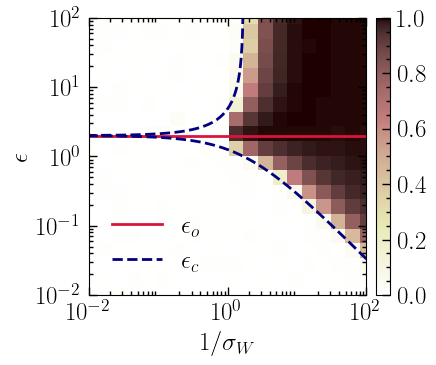

In [11]:
cmap = plt.get_cmap('pink_r')
new_cmap = truncate_colormap(cmap, 0.0, 1.)

set_rc(scale=1)
n_fig = 1

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(1./sigma_list, epsilon_list)

# Experimental phase diagram
im = axs.pcolormesh(X, Y, q2_list[:, :, 0],
                    vmin=0, vmax=1,
                    cmap=cmap,
                    shading='auto')

axs.plot(1./sig_list, epsilon_o_list_sa, 
         color='crimson', marker='', ls='-', lw=2, 
         label=r"$\epsilon_o$")

axs.plot(1./sig_list, epsilon_c_list_sa,
         color='navy', marker='', ls='--', lw=2,
         label=r"$\epsilon_c$")
axs.plot(1./sig_list, epsilon_c_n_list_sa,
         color='navy', marker='', ls='--', lw=2)

plt.legend(loc='lower left', facecolor='white', frameon=False, framealpha=1, edgecolor='k', fancybox=True)

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir2 + actf + "_" + "q2_exp.pdf", bbox_inches="tight")

plt.show()

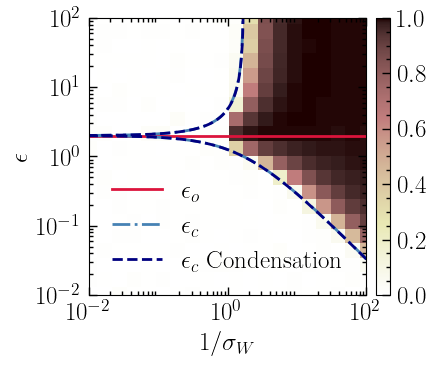

In [12]:
cmap = plt.get_cmap('pink_r')
new_cmap = truncate_colormap(cmap, 0.0, 1.)

set_rc(scale=1)
n_fig = 1

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

# Experimental phase diagram
im = axs.pcolormesh(1./X, Y, q2_list[:, :, 0],
                    vmin=0, vmax=1,
                    cmap=cmap,
                    shading='auto')

axs.plot(1./sig_list, epsilon_o_list, 
         color='crimson', marker='', ls='-', lw=2, 
         label=r"$\epsilon_o$")

axs.plot(1./sig_list, epsilon_c_list_sa,
         color='steelblue', marker='', ls='-.', lw=2,
         label=r"$\epsilon_c$")
axs.plot(1./sig_list, epsilon_c_n_list_sa,
         color='steelblue', marker='', ls='-.', lw=2)

axs.plot(1./sig_list, epsilon_c_list,
         color='navy', marker='', ls='--', lw=2,
         label=r"$\epsilon_c$ Condensation")
axs.plot(1./sig_list, epsilon_c_n_list,
         color='navy', marker='', ls='--', lw=2)

plt.legend(loc='lower left', facecolor='white', frameon=False, framealpha=1, edgecolor='k', fancybox=True)

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir2 + actf + "_" + "q2_exp_condensation_internal.pdf", bbox_inches="tight")

plt.show()

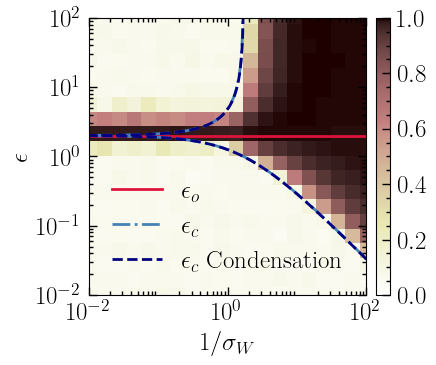

In [13]:
cmap = plt.get_cmap('pink_r')
new_cmap = truncate_colormap(cmap, 0.0, 1.)

set_rc(scale=1)
n_fig = 1

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

# Experimental phase diagram
im = axs.pcolormesh(1./X, Y, u_ab_list[:, :, 0],
                    vmin=0, vmax=1,
                    cmap=cmap,
                    shading='auto')

axs.plot(1./sig_list, epsilon_o_list, 
         color='crimson', marker='', ls='-', lw=2, 
         label=r"$\epsilon_o$")

axs.plot(1./sig_list, epsilon_c_list_sa,
         color='steelblue', marker='', ls='-.', lw=2,
         label=r"$\epsilon_c$")
axs.plot(1./sig_list, epsilon_c_n_list_sa,
         color='steelblue', marker='', ls='-.', lw=2)

axs.plot(1./sig_list, epsilon_c_list,
         color='navy', marker='', ls='--', lw=2,
         label=r"$\epsilon_c$ Condensation")
axs.plot(1./sig_list, epsilon_c_n_list,
         color='navy', marker='', ls='--', lw=2)

plt.legend(loc='lower left', facecolor='white', frameon=False, framealpha=1, edgecolor='k', fancybox=True)

nice_style(axs, 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs.set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir2 + actf + "_" + "u_ab_exp.pdf", bbox_inches="tight")

plt.show()

# Dynamic

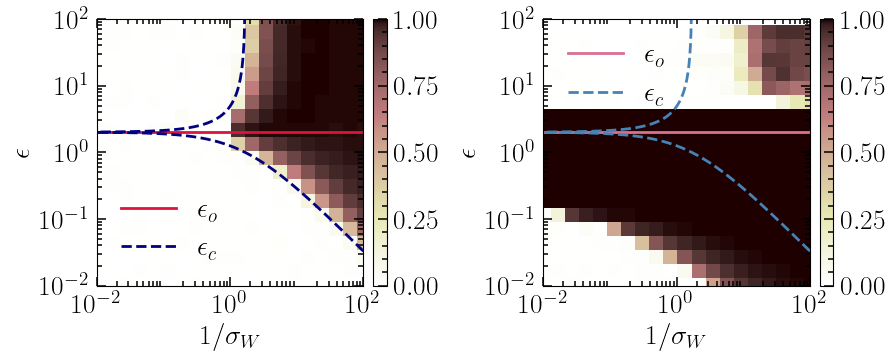

In [14]:
set_rc(scale=1.1)
n_fig = 2

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

im = axs[0].pcolormesh(
    1./X, Y, q2_list[:, :, 0],
    vmin=0, vmax=1,
    cmap='pink_r',
    shading='auto'
)

# Optimal epsilon
axs[0].plot(
    1./sig_list, epsilon_o_list, 
    color='crimson', marker='', ls='-', lw=2, 
    label=r"$\epsilon_o$"
)

# Critical step size
axs[0].plot(
    1./sig_list, epsilon_c_list, 
    color='navy', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)
axs[0].plot(
    1./sig_list, epsilon_c_n_list, 
    color='navy', marker='', ls='--', lw=2,
)

axs[0].legend(
    loc='lower left', 
    facecolor='white', 
    frameon=False, 
    framealpha=1, 
    edgecolor='k', 
    fancybox=True
)

nice_style(axs[0], 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs[0].set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)


# Experimental phase diagram
im = axs[1].pcolormesh(
    1./X, Y, q2_list[:, :, -1],
    vmin=0, vmax=1,
    cmap='pink_r',
    shading='auto'
)

# Optimal epsilon
axs[1].plot(
    1./sig_list, epsilon_o_list, 
    color='palevioletred', marker='', ls='-', lw=2, 
    label=r"$\epsilon_o$"
)

# # Critical step size
axs[1].plot(
    1./sig_list, epsilon_c_list, 
    color='steelblue', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)
axs[1].plot(
    1./sig_list, epsilon_c_n_list, 
    color='steelblue', marker='', ls='--', lw=2,
)

axs[1].legend(
    loc='upper left', 
    facecolor='white', 
    frameon=False, 
    framealpha=1, 
    edgecolor='k', 
    fancybox=True
)

nice_style(axs[1], 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs[1].set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir2 + "relu_exp_all.pdf", bbox_inches="tight")

plt.show()

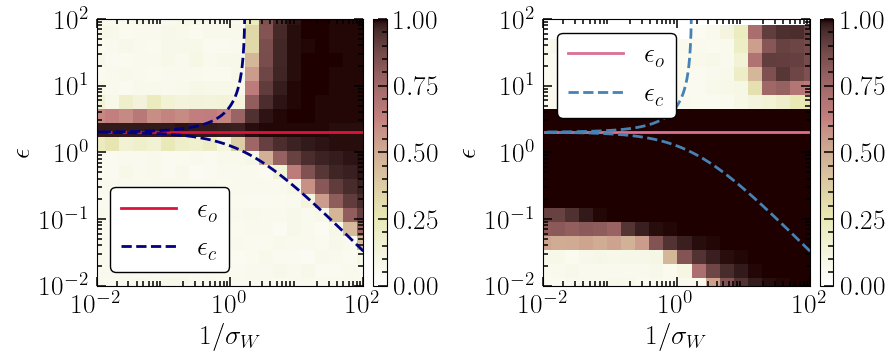

In [15]:
set_rc(scale=1.1)
n_fig = 2

fig, axs = plt.subplots(
    1, n_fig,
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

im = axs[0].pcolormesh(
    1./X, Y, u_ab_list[:, :, 0],
    vmin=0, vmax=1,
    cmap='pink_r',
    shading='auto'
)

# Optimal epsilon
axs[0].plot(
    1./sig_list, epsilon_o_list_sa, 
    color='crimson', marker='', ls='-', lw=2, 
    label=r"$\epsilon_o$"
)

# Critical step size
# epsilon_c_valid = np.where(mu2_list > 0, epsilon_c_list, np.nan)
axs[0].plot(
    1./sig_list, epsilon_c_list, 
    color='navy', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)
axs[0].plot(
    1./sig_list, epsilon_c_n_list, 
    color='navy', marker='', ls='--', lw=2,
)

axs[0].legend(
    loc='lower left', 
    facecolor='white', 
    frameon=True, 
    framealpha=1, 
    edgecolor='k', 
    fancybox=True
)

nice_style(axs[0], 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs[0].set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)


# Experimental phase diagram
im = axs[1].pcolormesh(
    1./X, Y, u_ab_list[:, :, -1],
    vmin=0, vmax=1,
    cmap='pink_r',
    shading='auto'
)

# Optimal epsilon
axs[1].plot(
    1./sig_list, epsilon_o_list_sa, 
    color='palevioletred', marker='', ls='-', lw=2, 
    label=r"$\epsilon_o$"
)

# # Critical step size
axs[1].plot(
    1./sig_list, epsilon_c_list, 
    color='steelblue', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)
axs[1].plot(
    1./sig_list, epsilon_c_n_list, 
    color='steelblue', marker='', ls='--', lw=2,
)

axs[1].legend(
    loc='upper left', 
    facecolor='white', 
    frameon=True, 
    framealpha=1, 
    edgecolor='k', 
    fancybox=True
)

nice_style(axs[1], 
           ylim=(np.min(epsilon_list), np.max(epsilon_list)),
           xlim=(np.min(sigma_list), np.max(sigma_list)),
           xlabel=r"$1/\sigma_W$",
           ylabel=r"$\epsilon$",
           logx=True, logy=True
          )

axs[1].set_aspect("equal", adjustable="box")

divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

plt.savefig(plot_dir2 + "relu_exp_uab_all.pdf", bbox_inches="tight")

plt.show()

/opt/miniconda3/envs/work/lib/python3.9/site-packages/global_chanju/paulplot/styles.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ax.figure.tight_layout()
/var/folders/60/czw76d8517j1d6_lrysbn7xc0000gn/T/ipykernel_29452/213638790.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


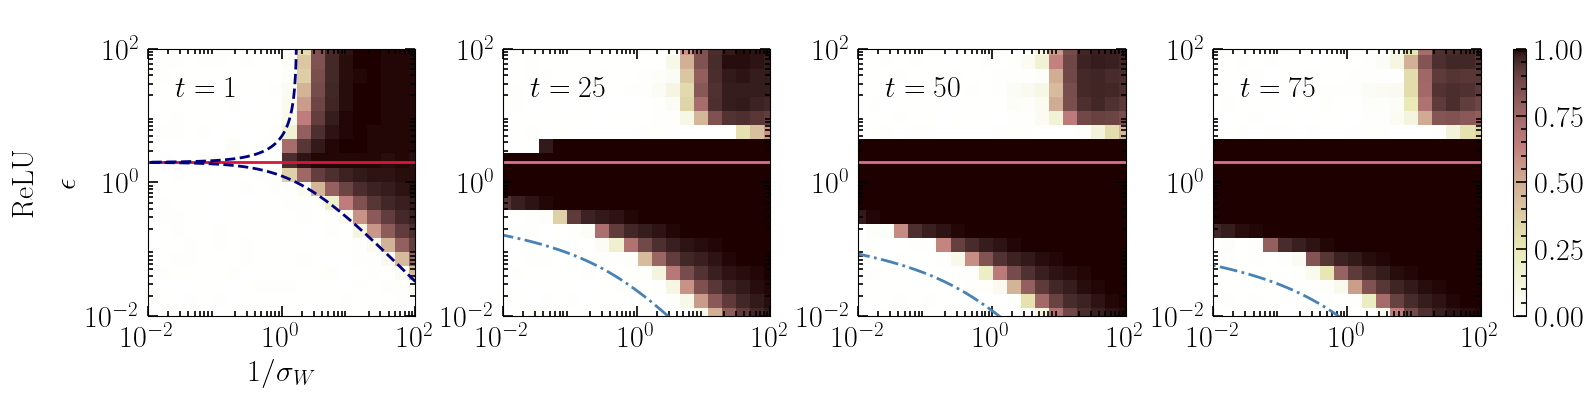

In [16]:
epoch_list = [1, 2, 3]

from matplotlib.gridspec import GridSpec

set_rc(scale=1.2)
n_fig = 5

fig = plt.figure(
    figsize=(n_fig*get_rc()['W']*get_rc()['r'],
             get_rc()['W']*get_rc()['r']),
)

X, Y = np.meshgrid(sigma_list, epsilon_list)

gs = GridSpec(
    1, 5,
    width_ratios=[0.1, 1, 1, 1, 1],
    wspace=0.4
)

ax_title = fig.add_subplot(gs[0, 0])
ax_title.axis("off")

ax_title.text(
    0.5, 0.5,
    "ReLU",
    rotation=90,
    va='center',
    ha='center',
#     fontsize=16
)

axes = []
pcm = None

# Initial
ax = fig.add_subplot(gs[0, 1])

pcm = ax.pcolormesh(
    1./X, Y, 
    q2_list[:, :, 0],
    vmin=0, vmax=1,
    cmap='pink_r',
    shading='auto'
)

# Optimal epsilon
ax.plot(
    1./sig_list, epsilon_o_list, 
    color='crimson', marker='', ls='-', lw=2, 
    label=r"$\epsilon_o$"
)

# Critical step size
ax.plot(
    1./sig_list, epsilon_c_list, 
    color='navy', marker='', ls='--', lw=2,
    label=r"$\epsilon_c$"
)
ax.plot(
    1./sig_list, epsilon_c_n_list, 
    color='navy', marker='', ls='--', lw=2,
)

ax.text(
    0.1, 0.85,
    transform=ax.transAxes,
    horizontalalignment='left', verticalalignment='center',
    color='k', 
    s=r"$t=1$"
)

nice_style(
    ax, 
    ylim=(1e-2, 1e2),
    xlim=(1e-2, 1e2),
        xlabel=r"$1/\sigma_W$",
        ylabel=r"$\epsilon$",
    logx=True, logy=True,
    xticks=[1e-2, 1e0, 1e2], yticks=[1e-2, 1e0, 1e2]
)

ax.set_aspect('equal')

axes.append(ax)

for i, epoch in enumerate(epoch_list):
    ax = fig.add_subplot(gs[0, i+2])

    pcm = ax.pcolormesh(
        1./X, Y, 
        q2_list[:, :, epoch],
        vmin=0, vmax=1,
        cmap='pink_r',
        shading='auto'
    )
    
    # Optimal epsilon
    ax.plot(
        1./sig_list, epsilon_o_list, 
        color='palevioletred', marker='', ls='-', lw=2, 
        label=r"$\epsilon_o$"
    )

    ax.plot(
        1./sig_list, epsilon_c_linear(sig_list, r=0.5, t=epoch*25),
        marker='', lw=2, ls='-.', color='steelblue',
        label=r"$\epsilon_c$ (Linear)"
    )

    ax.text(
        0.1, 0.85,
        transform=ax.transAxes,
        horizontalalignment='left', verticalalignment='center',
        color='k', 
        s=r"$t=%d$"%(epoch*25)
    )

    nice_style(
        ax, 
        ylim=(1e-2, 1e2),
        xlim=(1e-2, 1e2),
        logx=True, logy=True,
        xticks=[1e-2, 1e0, 1e2], yticks=[1e-2, 1e0, 1e2]
    )
    
    ax.set_aspect('equal')

    axes.append(ax)

    
cbar = fig.colorbar(
    pcm,
    ax=axes,
    location='right',
    shrink=0.77,
    pad=0.02
)

plt.tight_layout()

plt.savefig(plot_dir2+"relu_q2_time_dep.pdf")

plt.show()